# Импорты

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from dotenv import load_dotenv

from scipy import stats

import os

In [2]:
load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

DATABASE_URL = (
    f"postgresql://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(DATABASE_URL)

# DAU

In [4]:
with open("../sql/analytics/dau.sql", "r") as file:
    query = file.read()

dau_df = pd.read_sql(query, engine)

In [5]:
dau_df.head()

,event_date,daily_active_users
0,2025-05-31,2
1,2025-06-01,5
2,2025-06-02,13
3,2025-06-03,20
4,2025-06-04,26


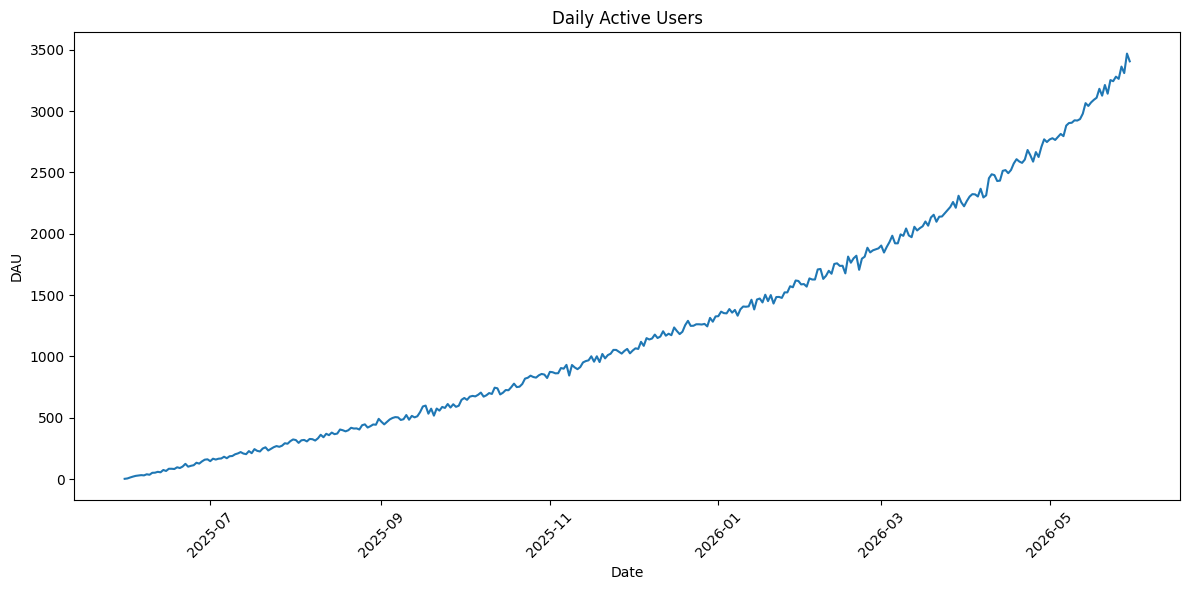

In [7]:
plt.figure(figsize=(12,6))

plt.plot(
    dau_df["event_date"],
    dau_df["daily_active_users"]
)

plt.title("Daily Active Users")

plt.xlabel("Date")

plt.ylabel("DAU")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Cohort retention

In [8]:
with open("../sql/analytics/retention.sql", "r") as file:
    retention_query = file.read()

retention_df = pd.read_sql(
    retention_query,
    engine
)
retention_df.head()

,cohort_date,retention_day,retained_users
0,2025-05-31,0,2
1,2025-05-31,2,1
2,2025-05-31,7,1
3,2025-05-31,8,1
4,2025-05-31,11,1


## Сводная таблица когорты

In [9]:
cohort_pivot = retention_df.pivot_table(
    index="cohort_date",

    columns="retention_day",

    values="retained_users"
)

cohort_pivot.head()

retention_day,0,1,2,3,4,5,6,7,8,9,...,354,355,356,357,358,359,360,361,362,363
cohort_date,,,,,,,,,,,,,,,,,,,,,
2025-05-31,2.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,...,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0
2025-06-01,5.0,1.0,3.0,1.0,3.0,2.0,3.0,2.0,2.0,5.0,...,2.0,1.0,NaN,3.0,1.0,1.0,2.0,3.0,2.0,1.0
2025-06-02,11.0,4.0,7.0,5.0,6.0,3.0,5.0,6.0,5.0,6.0,...,4.0,7.0,4.0,5.0,3.0,5.0,4.0,6.0,6.0,NaN
2025-06-03,13.0,2.0,4.0,2.0,3.0,3.0,3.0,4.0,1.0,2.0,...,2.0,2.0,3.0,2.0,1.0,1.0,2.0,2.0,NaN,NaN
2025-06-04,16.0,6.0,1.0,1.0,5.0,4.0,6.0,6.0,3.0,5.0,...,6.0,4.0,4.0,4.0,2.0,5.0,6.0,NaN,NaN,NaN


## Retention Heatmap

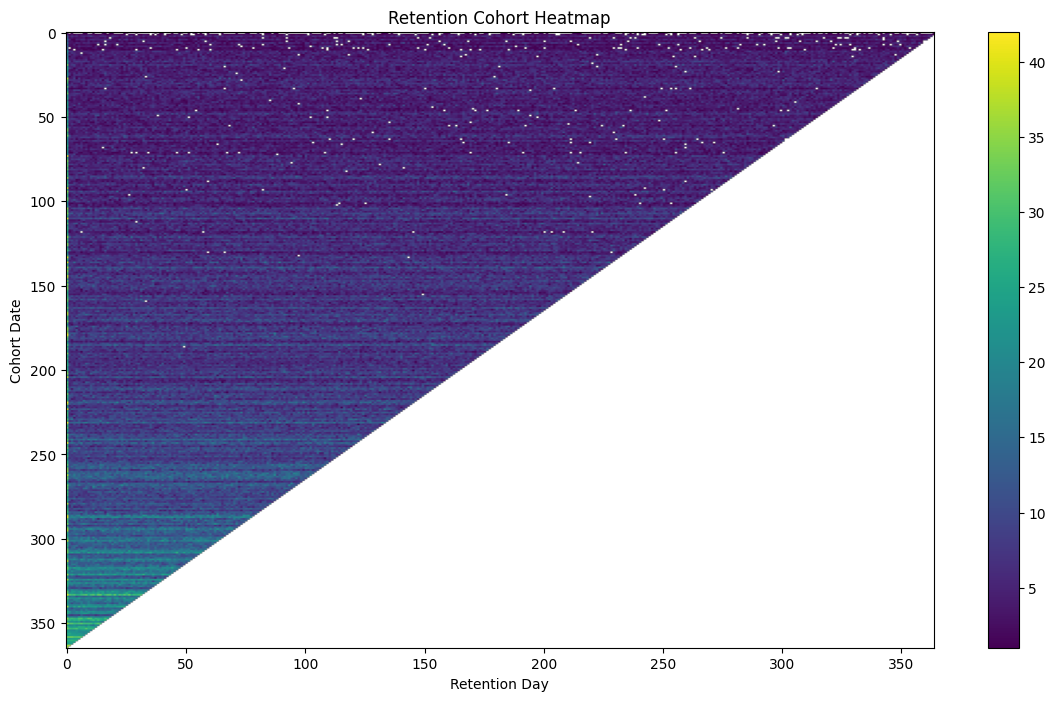

In [10]:
plt.figure(figsize=(14,8))

plt.imshow(
    cohort_pivot,
    aspect='auto'
)

plt.colorbar()

plt.title("Retention Cohort Heatmap")

plt.xlabel("Retention Day")

plt.ylabel("Cohort Date")

plt.show()

Уже на 5-10-й день удержание резко падает до темно-фиолетового цвета. Пользователи быстро теряют интерес к продукту и почти полностью уходят к 100 дню

# Анализ A/B теста

тестируем новый алгоритм рекомендаций

Гипотеза 0: Нет ощутимого прироста listening time.
Гипотеза 1: Test group слушают музыку дольше 

In [12]:
with open("../sql/analytics/ab.sql", "r") as file:
    ab_query = file.read()

ab_df = pd.read_sql(ab_query, engine)

In [14]:
ab_df

,group_name,avg_listen_duration
0,control,119.763181
1,test,119.793222


## Statistical Test

In [15]:
raw_ab_query = """

SELECT
    e.group_name,

    le.listen_duration

FROM experiments e

JOIN listening_events le
    ON e.user_id = le.user_id

"""

In [16]:
raw_ab_df = pd.read_sql(
    raw_ab_query,
    engine
)

делим группы

In [17]:
control = raw_ab_df[
    raw_ab_df["group_name"] == "control"
]["listen_duration"]

test = raw_ab_df[
    raw_ab_df["group_name"] == "test"
]["listen_duration"]

T-test

In [18]:
t_stat, p_value = stats.ttest_ind(
    control,
    test
)

print("T-statistic:", t_stat)

print("P-value:", p_value)

T-statistic: -0.1220435506177027
P-value: 0.9028646106312694


In [20]:
if p_value < 0.05:
    print("Гипотеза 1 подтверждена")
else:
    print("Гипотеза 0 подтверждена")

Гипотеза 0 подтверждена


## Segmentation Analysis

In [21]:
with open("../sql/analytics/segment.sql", "r") as file:
    segment_query = file.read()

segment_df = pd.read_sql(segment_query, engine)

segment_df

,subscription_type,avg_duration,total_streams
0,free,119.667828,521366
1,premium,119.783623,220430


Премиум и бесплатные пользователи демонстрируют сопоставимый уровень вовлеченности и количество прослушиваний, что указывает на отсутствие значимой разницы в удержании между сегментами.

# Export

In [22]:
dau_df.to_csv(
    "../data/exports/dau.csv",
    index=False
)

retention_df.to_csv(
    "../data/exports/retention.csv",
    index=False
)

segment_df.to_csv(
    "../data/exports/segments.csv",
    index=False
)